# **Integral Equations**

In the following we shall find a solution for the integral equation $\varphi(x) = 1 + \frac{1}{2}\int_0^1 e^{-xt} \varphi(t) dt$ using neural networks.

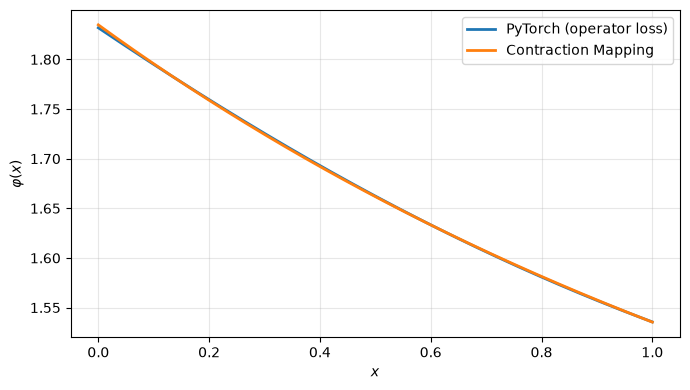

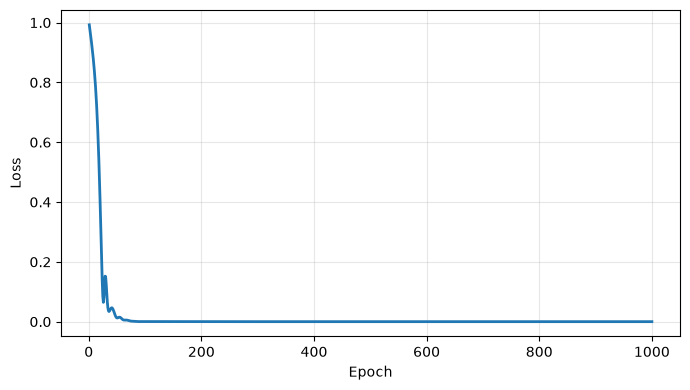

[NN ] phi(0) ≈ 1.8318120976,   phi(1) ≈ 1.5356067477
[CM ] phi(0) ≈ 1.8347584076,   phi(1) ≈ 1.5354450446


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# Repro & dtype
np.random.seed(0)
torch.manual_seed(0)
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)


# Grids & Quadrature (trapezoid on [0,1])
M = 4001                               # quadrature points for t in [0,1]
t_grid_np = np.linspace(0.0, 1.0, M).reshape(-1, 1)   # (M,1)

w_np = np.ones((M, 1))
w_np[0] = 0.5
w_np[-1] = 0.5
w_np *= 1.0 / (M - 1)                  # Δt (trapezoid weights)

t_grid = torch.tensor(t_grid_np, dtype=DTYPE)   # (M,1)
w = torch.tensor(w_np, dtype=DTYPE)             # (M,1)


# For plotting / comparing both methods
X_PLOT = np.linspace(0.0, 1.0, 1000).reshape(-1, 1).astype(np.float64)
X_PLOT_torch = torch.tensor(X_PLOT, dtype=DTYPE)



# Contraction Mapping solution (discretized)
# φ_{k+1}(x_i) = 1 + 1/2 * ∑_j e^{-x_i t_j} φ_k(t_j) w_j

def contraction_mapping_solution(n_t=2001, tol=1e-10, max_iter=10000):
    t = np.linspace(0.0, 1.0, n_t)
    x = t.copy()

    # trapezoid weights on [0,1]
    w = np.ones_like(t)
    w[0] = 0.5
    w[-1] = 0.5
    w *= 1.0 / (n_t - 1)

    K = np.exp(-np.outer(x, t))            # (n_t, n_t)

    phi = np.zeros_like(t)                 # φ_0 = 0

    for _ in range(max_iter):
        I = K @ (phi * w)                  # integral at each x_i
        phi_new = 1.0 + 0.5 * I

        if np.max(np.abs(phi_new - phi)) < tol:
            phi = phi_new
            break

        phi = phi_new

    # Interpolate to X_PLOT for comparison
    phi_plot = np.interp(X_PLOT[:,0], x, phi)

    return phi_plot


phi_cm_plot = contraction_mapping_solution()



# PyTorch model φ(x) with operator loss
# residual(x) = φ(x) - 1 - 1/2 * ∫_0^1 e^{-x t} φ(t) dt
# We'll pass x through y_true so the loss has the batch's x values.

class PhiNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)



model = PhiNet().to(dtype=DTYPE)



def g(x):  # g(x) = 1
    return torch.ones_like(x, dtype=DTYPE)



def integral_loss(y_true, y_pred):

    f_x = y_pred.to(DTYPE)                    # φ(x) at batch points (B,1)

    # Evaluate φ(t) at quadrature nodes (M,1) once per batch
    f_t = model(t_grid)

    # Kernel e^{-x t}: (B,1) @ (1,M) -> (B,M)
    x_batch = y_true.reshape(-1, 1).to(DTYPE)  # (B,1)

    X_times_T = x_batch @ t_grid.T             # (B,M)

    K = torch.exp(-X_times_T)                  # (B,M)


    # Weighted integral per x_i: (B,M) @ (M,1) -> (B,1)
    integral = K @ (f_t * w)


    residual = f_x - g(x_batch) - 0.5 * integral

    return torch.mean(residual**2)



optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



# Training data and training
N = 1000

x_train = np.linspace(0.0, 1.0, N).reshape(-1, 1).astype(np.float64)

x_train_torch = torch.tensor(x_train, dtype=DTYPE)

y_passthrough = x_train_torch.clone()  
# pass x as y_true so loss can read it


EPOCHS = 1000

history = {"loss": []}


for epoch in range(EPOCHS):

    optimizer.zero_grad()

    prediction = model(x_train_torch)

    loss = integral_loss(y_passthrough, prediction)

    loss.backward()

    optimizer.step()

    history["loss"].append(loss.item())



# Predict NN solution on X_PLOT
with torch.no_grad():
    phi_nn_plot = model(X_PLOT_torch).cpu().numpy()



# Plot both solutions on the same figure
plt.figure(figsize=(7, 4))

plt.plot(
    X_PLOT,
    phi_nn_plot,
    linewidth=2,
    label="PyTorch (operator loss)"
)

plt.plot(
    X_PLOT,
    phi_cm_plot,
    linewidth=2,
    label="Contraction Mapping"
)

plt.xlabel("$x$")
plt.ylabel("$\\varphi(x)$")

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()



# Plot loss vs epochs
plt.figure(figsize=(7, 4))

plt.plot(
    np.arange(1, EPOCHS+1),
    history["loss"],
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()



# Print key values for both methods
print(
    f"[NN ] phi(0) ≈ {phi_nn_plot[0,0]:.10f},   "
    f"phi(1) ≈ {phi_nn_plot[-1,0]:.10f}"
)

print(
    f"[CM ] phi(0) ≈ {phi_cm_plot[0]:.10f},   "
    f"phi(1) ≈ {phi_cm_plot[-1]:.10f}"
)

Check the error between the NN-solution and the Contraction Principle-solution.

In [2]:
# residual r(x) = φ_nn(x) - 1 - 1/2 * ∫ e^{-x t} φ_nn(t) dt

with torch.no_grad():

    f_t = model(t_grid)                              # (M,1)

    # Kernel e^{-x t}: (B,1) @ (1,M) -> (B,M)
    KxT = torch.exp(-X_PLOT_torch @ t_grid.T)        # (B,M)

    # Integral: (B,M) @ (M,1) -> (B,1)
    integral = KxT @ (f_t * w)                       # (B,1)

    r = phi_nn_plot - 1.0 - 0.5 * integral.cpu().numpy()


print("NN residual: max |r| =", float(np.max(np.abs(r))))

NN residual: max |r| = 0.0029460149675114566


 **An ill-posed problem**

Consider the Poisson kernel defined by
$
K(r,\theta) = \frac{1-r^2}{1-2r\cos\theta+r^2},
$
for $\theta \in [0,2\pi]$ and $0 \le r < 1$.

 We wish to find a function $\varphi: [0,2\pi] \to \mathbb{R}$ that satisfies the integral equation
$
\int_0^{2\pi} K(r,\theta) \, \varphi(\theta) \, d\theta = r.
$

Epoch 1/40 - loss: 9.689581e-01
Epoch 2/40 - loss: 3.365355e-02
Epoch 3/40 - loss: 9.501302e-03
Epoch 4/40 - loss: 8.071922e-03
Epoch 5/40 - loss: 7.992747e-03
Epoch 6/40 - loss: 7.961040e-03
Epoch 7/40 - loss: 7.928166e-03
Epoch 8/40 - loss: 7.893411e-03
Epoch 9/40 - loss: 7.857008e-03
Epoch 10/40 - loss: 7.819208e-03
Epoch 11/40 - loss: 7.780216e-03
Epoch 12/40 - loss: 7.740199e-03
Epoch 13/40 - loss: 7.699288e-03
Epoch 14/40 - loss: 7.657579e-03
Epoch 15/40 - loss: 7.615141e-03
Epoch 16/40 - loss: 7.572009e-03
Epoch 17/40 - loss: 7.528194e-03
Epoch 18/40 - loss: 7.483676e-03
Epoch 19/40 - loss: 7.438409e-03
Epoch 20/40 - loss: 7.392320e-03
Epoch 21/40 - loss: 7.345307e-03
Epoch 22/40 - loss: 7.297239e-03
Epoch 23/40 - loss: 7.247955e-03
Epoch 24/40 - loss: 7.197263e-03
Epoch 25/40 - loss: 7.144935e-03
Epoch 26/40 - loss: 7.090709e-03
Epoch 27/40 - loss: 7.034280e-03
Epoch 28/40 - loss: 6.975304e-03
Epoch 29/40 - loss: 6.913388e-03
Epoch 30/40 - loss: 6.848096e-03
Epoch 31/40 - loss:

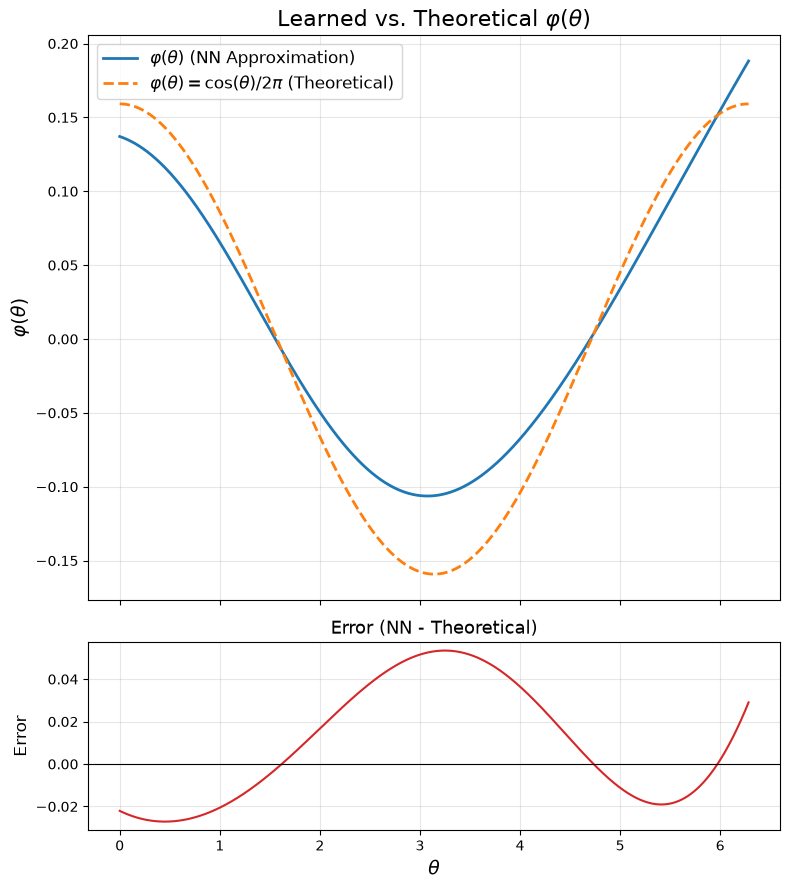

In [3]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Use double precision to match TensorFlow's float64 setup exactly
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Shared deterministic initializer -------------------------------------
# TensorFlow's and PyTorch's default initializers (Glorot vs Kaiming) draw
# from *different* random number generators, so "the same seed" in each
# framework does NOT produce the same weights -- there's no shared RNG
# between them. To get a result that's identical across both frameworks
# independently (no file exchange, no run-order dependency), we generate
# the initial weights ourselves with plain NumPy (a single common RNG) and
# load them into the model explicitly. This exact function also appears in
# the TensorFlow script, so both scripts are self-contained and produce the
# same starting point on their own.
def glorot_uniform(shape, seed):
    rng = np.random.RandomState(seed)
    fan_in, fan_out = shape
    limit = np.sqrt(6.0 / (fan_in + fan_out))
    return rng.uniform(-limit, limit, size=shape).astype(np.float64)

def get_initial_weights():
    W1 = glorot_uniform((1, 40), seed=100);  b1 = np.zeros(40, dtype=np.float64)
    W2 = glorot_uniform((40, 20), seed=200); b2 = np.zeros(20, dtype=np.float64)
    W3 = glorot_uniform((20, 1), seed=300);  b3 = np.zeros(1, dtype=np.float64)
    return W1, b1, W2, b2, W3, b3

# Define the Poisson kernel using PyTorch operations
def poisson_kernel(r, theta):
    return (1 - r**2) / (1 - 2 * r * torch.cos(theta) + r**2)

# Define the target function f(r) = r
def f_target(r):
    return r

# --- Exact analytical solution for phi(theta) -----------------------------
# The integral equation being enforced is
#     I(r) = ∫₀^(2π) K(r,θ) φ(θ) dθ = r   for all r in [0,1)
# Writing φ(θ) as a Fourier series φ(θ) = a0 + Σ_n [a_n cos(nθ) + b_n sin(nθ)]
# and using the Poisson-kernel identity
#     ∫₀^(2π) K(r,θ) cos(nθ) dθ = 2π r^n cos(nθ0)|_{θ0=0} = 2π r^n
#     ∫₀^(2π) K(r,θ) sin(nθ) dθ = 0                      (since θ0 = 0)
# matching powers of r on both sides forces: a0 = 0, a_1 = 1/(2π),
# a_n = 0 for n >= 2, and leaves all b_n undetermined (the equation only
# constrains the θ0=0 direction). The minimal-norm/particular solution --
# and the one the network is implicitly biased toward -- is therefore:
#     phi_exact(theta) = cos(theta) / (2*pi)
# This was verified numerically: plugging it back into the Riemann sum
# reproduces I(r) = r to within floating-point error (~1e-14) for r in [0,1).
def phi_exact_fn(theta):
    return np.cos(theta) / (2 * np.pi)

# Generate training data: sample theta values uniformly in [0, 2π]
theta_vals = np.linspace(0, 2*np.pi, 4000).reshape(-1, 1)

# Use a uniform Riemann sum for integration over theta in [0,2π]
dtheta = (2*np.pi) / len(theta_vals)

# Build the neural network model to approximate φ(θ)
class PhiNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 40)
        self.act1 = nn.SiLU()      # equivalent to 'swish'
        self.fc2 = nn.Linear(40, 20)
        self.act2 = nn.Tanh()
        self.fc3 = nn.Linear(20, 1)

    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return self.fc3(x)

model = PhiNet().to(device)

# Load the same shared deterministic initial weights used in the TF script.
# Keras Dense kernel shape is (in, out); PyTorch Linear weight is (out, in) -> transpose.
W1, b1, W2, b2, W3, b3 = get_initial_weights()
with torch.no_grad():
    model.fc1.weight.copy_(torch.tensor(W1.T)); model.fc1.bias.copy_(torch.tensor(b1))
    model.fc2.weight.copy_(torch.tensor(W2.T)); model.fc2.bias.copy_(torch.tensor(b2))
    model.fc3.weight.copy_(torch.tensor(W3.T)); model.fc3.bias.copy_(torch.tensor(b3))

# Generate a set of r values in [0,1] for evaluating the loss function
r_samples = np.linspace(0, 1, 5000, endpoint=False).reshape(-1, 1)

# Convert theta_vals / r_samples to PyTorch tensors
theta_tensor = torch.tensor(theta_vals, dtype=torch.float64, device=device)
r_tensor = torch.tensor(r_samples, dtype=torch.float64, device=device)

# The kernel K(r, theta) does NOT depend on the model's parameters -- it only
# depends on the fixed r_samples/theta_vals grids, so we precompute it once
# instead of rebuilding a (5000,4000) matrix on every single step.
KERNEL = poisson_kernel(r_tensor, theta_tensor.reshape(1, -1))  # shape: (5000, 4000), constant

# Define a custom loss function based on the integral equation:
# For each r in r_samples, we approximate the integral
#    I(r) = ∫₀^(2π) K(r,θ) φ(θ) dθ,
# and enforce I(r) ≈ f_target(r) = r.
def custom_loss():
    # Evaluate the network on the fixed integration points (theta_vals) to obtain φ(θ).
    phi_vals = model(theta_tensor)  # shape: (4000, 1)
    # Riemann-sum integral for every r at once: (5000,4000) @ (4000,1) -> (5000,1)
    integrals = dtheta * (KERNEL @ phi_vals)
    # The residual for each r is the difference between the approximate integral and r.
    residuals = integrals - r_tensor
    # The loss is the mean squared residual.
    loss_value = torch.mean(residuals**2)
    return loss_value

# Compile the model using the Adam optimizer.
# NOTE: Keras' Adam default epsilon is 1e-7, while PyTorch's default is 1e-8 --
# match it explicitly, or the two optimizers take slightly different step sizes.
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, betas=(0.9, 0.999), eps=1e-7)

# Train the model.
# IMPORTANT: the TensorFlow script calls
#     model.fit(dummy_input, dummy_target, epochs=40, batch_size=32, ...)
# with dummy_input of size 1000. Even though custom_loss ignores the actual
# batch content (it always recomputes the same integral from theta_vals and
# r_samples), Keras still runs one train_step per batch: ceil(1000/32) = 32
# steps per epoch -> 40 * 32 = 1280 Adam updates in total, not 40. We
# replicate that here with a nested loop so the number of optimizer steps
# matches exactly.
epochs = 40
dummy_size = 1000
batch_size = 32
steps_per_epoch = int(np.ceil(dummy_size / batch_size))  # 32

for epoch in range(epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        optimizer.zero_grad()
        loss = custom_loss()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss/steps_per_epoch:.6e}")

# After training, evaluate the learned function φ(θ) on a dense grid for visualization.
theta_plot = np.linspace(0, 2*np.pi, 1000).reshape(-1, 1)
theta_plot_tensor = torch.tensor(theta_plot, dtype=torch.float64, device=device)

model.eval()
with torch.no_grad():
    phi_learned = model(theta_plot_tensor).cpu().numpy()

# Evaluate the exact analytical solution on the same grid for comparison
phi_theoretical = phi_exact_fn(theta_plot)

# Report how close the NN approximation is to the theoretical curve
mse_vs_theory = np.mean((phi_learned - phi_theoretical) ** 2)
print(f"MSE(NN vs theoretical phi) = {mse_vs_theory:.6e}")

# Plot the learned function φ(θ) against the exact theoretical solution
fig, axes = plt.subplots(2, 1, figsize=(8, 9), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(theta_plot, phi_learned, label=r"$\varphi(\theta)$ (NN Approximation)",
             linewidth=2, color='tab:blue')
axes[0].plot(theta_plot, phi_theoretical, label=r"$\varphi(\theta) = \cos(\theta)/2\pi$ (Theoretical)",
             linewidth=2, linestyle='--', color='tab:orange')
axes[0].set_title(r"Learned vs. Theoretical $\varphi(\theta)$", fontsize=16)
axes[0].set_ylabel(r"$\varphi(\theta)$", fontsize=14)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=12)

axes[1].plot(theta_plot, phi_learned - phi_theoretical, color='tab:red', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title("Error (NN - Theoretical)", fontsize=13)
axes[1].set_xlabel(r"$\theta$", fontsize=14)
axes[1].set_ylabel("Error", fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()